# Shakespeare Text Generation (using RNN LSTM)

## Experiment overview

In this experiment we will use character-based [Recurrent Neural Network](https://en.wikipedia.org/wiki/Recurrent_neural_network) (RNN) to generate a Shakespeare's-like text based on the Shakespeare dataset from [The Unreasonable Effectiveness of Recurrent Neural Networks]

## Import dependencies

In [ ]:
# Selecting Tensorflow version v2 (the command is relevant for Colab only).
# %tensorflow_version 2.x

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import platform
import time
import pathlib
import os

print("Python version:", platform.python_version())
print("Tensorflow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

Python version: 3.8.12
Tensorflow version: 2.4.1
Keras version: 2.4.0


## Download the dataset

In [2]:
cache_dir = "./tmp"
dataset_file_name = "shakespeare.txt"
dataset_file_origin = (
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

dataset_file_path = tf.keras.utils.get_file(
    fname=dataset_file_name,
    origin=dataset_file_origin,
    cache_dir=pathlib.Path(cache_dir).absolute(),
)

print(dataset_file_path)

1122304/1115394 [==============================] - 0s 0us/step
/tmp/.keras/datasets/shakespeare.txt


## Analyze the dataset

In [3]:
# Reading the database file.
text = open(dataset_file_path, mode="r").read()

print("Length of text: {} characters".format(len(text)))
# There are more than 1.1 million characters in this corpus.

Length of text: 1115394 characters


In [4]:
# The unique characters in the file
vocab = sorted(set(text))

print("{} unique characters".format(len(vocab)))
print("vocab:", vocab)

65 unique characters
vocab: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## Process the dataset

### Vectorize the text

Before feeding the text to our RNN we need to convert the text from a sequence of characters to a sequence of numbers. To do so we will detect all unique characters in the text, form a vocabulary out of it and replace each character with its index in the vocabulary.

In [6]:
# Map characters to their indices in vocabulary.
char2index = {char: index for index, char in enumerate(vocab)}

print("{")
for char, _ in zip(char2index, range(20)):
    print("  {:4s}: {:3d},".format(repr(char), char2index[char]))
print("  ...\n}")

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '$' :   3,
  '&' :   4,
  "'" :   5,
  ',' :   6,
  '-' :   7,
  '.' :   8,
  '3' :   9,
  ':' :  10,
  ';' :  11,
  '?' :  12,
  'A' :  13,
  'B' :  14,
  'C' :  15,
  'D' :  16,
  'E' :  17,
  'F' :  18,
  'G' :  19,
  ...
}


In [7]:
# Map character indices to characters from vocabulary so that later on we can do mapping from
# any index to char
index2char = np.array(vocab)
print(index2char)
print(type(index2char))

['\n' ' ' '!' '$' '&' "'" ',' '-' '.' '3' ':' ';' '?' 'A' 'B' 'C' 'D' 'E'
 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W'
 'X' 'Y' 'Z' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o'
 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
<class 'numpy.ndarray'>


In [8]:
# Convert chars in text to indices.
text_as_int = np.array([char2index[char] for char in text])

print("text_as_int length: {}".format(len(text_as_int)))
print("{} --> {}".format(repr(text[:15]), repr(text_as_int[:15])))

text_as_int length: 1115394
'First Citizen:\n' --> array([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0])


Now that we understand good enough about the data, lets get to the training phase.

**The prediction task**

Given a character, or a sequence of characters, what is the most probable next character? This is the task you're training the model to perform. The input to the model will be a sequence of characters, and you train the model to predict the output—the following character at each time step.

Since RNNs maintain an internal state that depends on the previously seen elements, given all the characters computed until this moment, what is the next character?

**Create training examples and targets**



## Create training sequences

In [9]:
# The maximum length sentence we want for a single input in characters.
sequence_length = 100
examples_per_epoch = len(text) // (sequence_length + 1)

print("examples_per_epoch:", examples_per_epoch)

examples_per_epoch: 11043


In [10]:
# Create training dataset.
char_dataset = tf.data.Dataset.from_tensor_slices(
    text_as_int
)  # used to convert it to tensor based dataset called
# character dataset

for char in char_dataset.take(5):
    print(index2char[char.numpy()])
# the above for loop will go through tensors one by one and
# print the index to character.
print(type(char_dataset))

F
i
r
s
t
<class 'tensorflow.python.data.ops.dataset_ops.TensorSliceDataset'>


2022-03-27 14:23:56.111371: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-03-27 14:23:56.111766: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
for char in char_dataset.take(5):
    print(char.numpy())
# the above for loop will go through tensors one by one and
# print the indexes.

18
47
56
57
58


The batch method lets us easily convert these individual characters to sequences of the desired size.

In [15]:
# Generate batched sequences out of the char_dataset.
sequences = char_dataset.batch(sequence_length + 1, drop_remainder=True)
# drop_remainder=True will drop the remainder after dividing the corpus into sequence_length

# Sequences size is the same as examples_per_epoch.
print("Sequences count: {}".format(len(list(sequences.as_numpy_iterator()))))
print()

# Sequences examples....This will print my first 5 sequences
# print(index2char)
for item in sequences.take(5):
    # print(item.numpy())
    print(repr("".join(index2char[item.numpy()])))

Sequences count: 11043

'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou '
'are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you k'
"now Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us ki"
"ll him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be d"
'one: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citi'


**drop_remainder=True has made us drop the last 51 characters.**

For each sequence, duplicate and shift it to form the input and target text. For example, say `sequence_length` is `4` and our text is `Hello`. The input sequence would be `Hell`, and the target sequence `ello`.

In [ ]:
def split_input_target(chunk):
    input_text = chunk[:-1]  # SI=0 to second last index
    target_text = chunk[1:]  # SI=1 to the last index
    return input_text, target_text

In [ ]:
dataset = sequences.map(split_input_target)


print("dataset size: {}".format(len(list(dataset.as_numpy_iterator()))))

dataset size: 11043


Print the first example input and target values:

In [ ]:
for input_example, target_example in dataset.take(1):
    print("Input sequence size:", repr(len(input_example.numpy())))
    print("Target sequence size:", repr(len(target_example.numpy())))
    print()
    print("Input:", repr("".join(index2char[input_example.numpy()])))
    print("Target:", repr("".join(index2char[target_example.numpy()])))

Input sequence size: 100
Target sequence size: 100

Input: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'
Target: 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou '


In [ ]:
for input_example, target_example in dataset.take(2):
    print("Input sequence size:", repr(len(input_example.numpy())))
    print("Target sequence size:", repr(len(target_example.numpy())))
    print()
    print("Input:", repr("".join(index2char[input_example.numpy()])))
    print("Target:", repr("".join(index2char[target_example.numpy()])))

Input sequence size: 100
Target sequence size: 100

Input: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'
Target: 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou '
Input sequence size: 100
Target sequence size: 100

Input: 'are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you '
Target: 're all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you k'


Each index of these vectors are processed as one time step. For the input at time step 0, the model receives the index for "F" and trys to predict the index for "i" as the next character. At the next timestep, it does the same thing but the RNN considers the previous step context in addition to the current input character.

In [ ]:
for i, (input_idx, target_idx) in enumerate(zip(input_example[:5], target_example[:5])):
    print("Step {:2d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(index2char[input_idx])))
    print(
        "  expected output: {} ({:s})".format(target_idx, repr(index2char[target_idx]))
    )

Step  0
  input: 39 ('a')
  expected output: 56 ('r')
Step  1
  input: 56 ('r')
  expected output: 43 ('e')
Step  2
  input: 43 ('e')
  expected output: 1 (' ')
Step  3
  input: 1 (' ')
  expected output: 39 ('a')
Step  4
  input: 39 ('a')
  expected output: 50 ('l')


## Split training sequences into batches

We used `tf.data` to split the text into manageable sequences. But before feeding this data into the model, we need to shuffle the data and pack it into batches.

Earlier, for explaination purpose, we created seq_length=100, which was my batch_size which we were passing everywhere.

Now, we will change it to 64.

In [ ]:
# Batch size.
BATCH_SIZE = 64


BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

<BatchDataset shapes: ((64, 100), (64, 100)), types: (tf.int64, tf.int64)>

In [ ]:
print("Batched dataset size: {}".format(len(list(dataset.as_numpy_iterator()))))

Batched dataset size: 172


In [ ]:
for input_text, target_text in dataset.take(1):
    print("1st batch: input_text:", input_text)
    print("===================================================")
    print("1st batch: target_text:", target_text)

1st batch: input_text: tf.Tensor(
[[59 52 41 ...  0 32 53]
 [ 1 46 43 ...  1 58 46]
 [58 53  1 ... 43  1 50]
 ...
 [32 47 57 ...  1 46 47]
 [57  1 46 ... 39 41 49]
 [ 5  1 58 ... 47 52 45]], shape=(64, 100), dtype=int64)
1st batch: target_text: tf.Tensor(
[[52 41 50 ... 32 53  1]
 [46 43 39 ... 58 46 39]
 [53  1 51 ...  1 50 53]
 ...
 [47 57  1 ... 46 47 57]
 [ 1 46 47 ... 41 49  1]
 [ 1 58 46 ... 52 45  1]], shape=(64, 100), dtype=int64)


In [ ]:
for input_text, target_text in dataset.take(2):
    print("1st batch: input_text:", input_text)
    print("===================================================")
    print("1st batch: target_text:", target_text)

1st batch: input_text: tf.Tensor(
[[47 57  1 ... 43  1 40]
 [56  6  1 ...  0 24 17]
 [ 0 21 44 ... 61 43 56]
 ...
 [57 47 52 ... 56  1 58]
 [49 53 50 ... 47 58 46]
 [47 43 57 ... 43  0 32]], shape=(64, 100), dtype=int64)
1st batch: target_text: tf.Tensor(
[[57  1 59 ...  1 40 43]
 [ 6  1 57 ... 24 17 27]
 [21 44  1 ... 43 56  8]
 ...
 [47 52  6 ...  1 58 46]
 [53 50 42 ... 58 46 39]
 [43 57 58 ...  0 32 53]], shape=(64, 100), dtype=int64)
1st batch: input_text: tf.Tensor(
[[59 56 43 ... 14 63  1]
 [21 26 19 ... 59 56  1]
 [ 5 50 50 ...  0 13 52]
 ...
 [53 51 43 ... 39 49 43]
 [ 6  0 13 ... 57 46 53]
 [ 0  0 14 ... 50 10  0]], shape=(64, 100), dtype=int64)
1st batch: target_text: tf.Tensor(
[[56 43  1 ... 63  1 46]
 [26 19  1 ... 56  1 46]
 [50 50  1 ... 13 52 42]
 ...
 [51 43  6 ... 49 43  1]
 [ 0 13 52 ... 46 53 61]
 [ 0 14 17 ... 10  0 13]], shape=(64, 100), dtype=int64)


## Build the model



In [ ]:
# OPTIONAL CELL

# Let's do a quick detour and see how Embeding layer works.
# It takes several char indices sequences (batch) as an input.
# It encodes every character of every sequence to a vector of tmp_embeding_size length.
tmp_vocab_size = 10
tmp_embeding_size = 5
tmp_input_length = 8
tmp_batch_size = 2

tmp_model = tf.keras.models.Sequential()
tmp_model.add(
    tf.keras.layers.Embedding(
        input_dim=tmp_vocab_size,
        output_dim=tmp_embeding_size,
        input_length=tmp_input_length,
    )
)
# The model will take as input an integer matrix of size (batch, input_length).
# The largest integer (i.e. word index) in the input should be no larger than 9 (tmp_vocab_size).
# Now model.output_shape == (None, 10, 64), where None is the batch dimension.
tmp_input_array = np.random.randint(
    low=0, high=tmp_vocab_size, size=(tmp_batch_size, tmp_input_length)
)
tmp_model.compile("rmsprop", "mse")
tmp_output_array = tmp_model.predict(tmp_input_array)

print("tmp_input_array shape:", tmp_input_array.shape)
print("tmp_input_array:")
print(tmp_input_array)
print()
print("tmp_output_array shape:", tmp_output_array.shape)
print("tmp_output_array:")
print(tmp_output_array)

tmp_input_array shape: (2, 8)
tmp_input_array:
[[6 5 6 0 1 6 3 2]
 [6 1 2 3 8 5 2 1]]

tmp_output_array shape: (2, 8, 5)
tmp_output_array:
[[[ 0.02733255 -0.0290539  -0.03428723 -0.02458149  0.03707831]
  [ 0.02135653  0.02240772 -0.03534668 -0.04366268 -0.03763422]
  [ 0.02733255 -0.0290539  -0.03428723 -0.02458149  0.03707831]
  [-0.04124379  0.04470154  0.04595766  0.04752803  0.0098709 ]
  [-0.02362044  0.04906615 -0.02749729  0.00404691  0.00608985]
  [ 0.02733255 -0.0290539  -0.03428723 -0.02458149  0.03707831]
  [-0.01694158  0.0020512  -0.01385347  0.01514566 -0.04696305]
  [ 0.01029886  0.02688647 -0.01291139  0.02166779  0.00594584]]

 [[ 0.02733255 -0.0290539  -0.03428723 -0.02458149  0.03707831]
  [-0.02362044  0.04906615 -0.02749729  0.00404691  0.00608985]
  [ 0.01029886  0.02688647 -0.01291139  0.02166779  0.00594584]
  [-0.01694158  0.0020512  -0.01385347  0.01514566 -0.04696305]
  [-0.01507919  0.02763743 -0.02820889  0.0404514  -0.03696238]
  [ 0.02135653  0.02240772 

In [ ]:
len(vocab)

65

In [ ]:
vocab_size = len(vocab)


embedding_dim = 256

rnn_units = 1024

In [ ]:
def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.models.Sequential()

    model.add(
        tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            batch_input_shape=[batch_size, None],
        )
    )

    model.add(
        tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal(),
        )
    )

    model.add(tf.keras.layers.Dense(vocab_size))

    return model

In [ ]:
model = build_model(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE,
)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (64, None, 256)           16640     
_________________________________________________________________
lstm (LSTM)                  (64, None, 1024)          5246976   
_________________________________________________________________
dense (Dense)                (64, None, 65)            66625     
Total params: 5,330,241
Trainable params: 5,330,241
Non-trainable params: 0
_________________________________________________________________


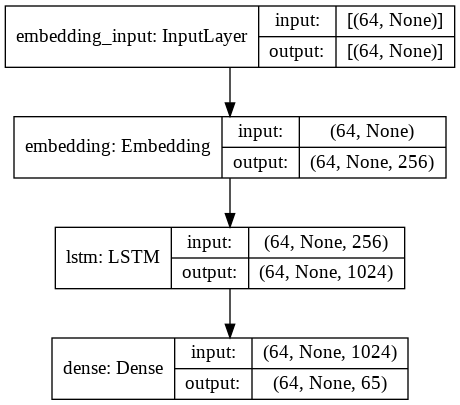

In [ ]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
)

## Try the model

Now run the model to see that it behaves as expected.

First check the shape of the output:

In [ ]:
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(
        example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)"
    )

(64, 100, 65) # (batch_size, sequence_length, vocab_size)


This is not very understandable to us as we are yet to train the model.

In the above example the sequence length of the input is 100 but the model can be run on inputs of any length:

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (64, None, 256)           16640     
_________________________________________________________________
lstm (LSTM)                  (64, None, 1024)          5246976   
_________________________________________________________________
dense (Dense)                (64, None, 65)            66625     
Total params: 5,330,241
Trainable params: 5,330,241
Non-trainable params: 0
_________________________________________________________________


To get actual predictions from the model you need to sample from the output distribution, to get actual character indices. This distribution is defined by the logits over the character vocabulary.

Note: It is important to sample from this distribution as taking the argmax of the distribution can easily get the model stuck in a loop.

Try it for the first example in the batch:

In [ ]:
sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices, axis=-1).numpy()

This gives us, at each timestep, a prediction of the next character index:

In [ ]:
sampled_indices

array([ 8, 12, 11, 39,  0, 14,  3, 45, 60, 48, 51,  3, 39, 22, 62, 29,  4,
       32, 55, 62, 33,  5, 48, 12, 14,  4, 40, 50, 44, 39,  4, 35, 58,  4,
        6, 47, 42, 30, 60, 41, 38, 12, 25,  5, 57, 47, 36, 42, 39, 64, 61,
       47, 22,  8, 11, 42, 19,  0, 37, 35, 18, 23, 50, 62,  5, 29, 33, 29,
       56, 47, 58, 37, 11, 30, 60, 34, 49, 54, 42,  0, 15, 36,  4,  4, 37,
        7, 13,  1, 36, 10, 28, 44, 13, 61, 45, 55, 14, 25, 17,  3])

Decode these to see the text predicted by this untrained model:

In [ ]:
print("Input: \n", repr("".join(index2char[input_example_batch[0]])))
print()
print("Next Char Predictions: \n", repr("".join(index2char[sampled_indices])))

Input: 
 'as not ignoble of descent;\nAnd meaner than myself have had like fortune.\nBut as this title honours m'

Next Char Predictions: 
 ".?;a\nB$gvjm$aJxQ&TqxU'j?B&blfa&Wt&,idRvcZ?M'siXdazwiJ.;dG\nYWFKlx'QUQritY;RvVkpd\nCX&&Y-A X:PfAwgqBME$"


**Why is the prediction so bad?**

Thats because, we have yet not trained the model. But this will immensely help us to compare with the trained model later on.

## Train the model

At this point the problem can be treated as a standard classification problem. Given the previous RNN state, and the input this time step, predict the class of the next character.

### Attach an optimizer, and a loss function


In [ ]:
# An objective function.
# The function is any callable with the signature scalar_loss = fn(y_true, y_pred).
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
        y_true=labels, y_pred=logits, from_logits=True
    )


example_batch_loss = loss(target_example_batch, example_batch_predictions)

print(
    "Prediction shape: ",
    example_batch_predictions.shape,
    " # (batch_size, sequence_length, vocab_size)",
)
print("scalar_loss:      ", example_batch_loss.numpy().mean())

Prediction shape:  (64, 100, 65)  # (batch_size, sequence_length, vocab_size)
scalar_loss:       4.174504


In [ ]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam_optimizer, loss=loss)

### Configure checkpoints

Use a tf.keras.callbacks.ModelCheckpoint to ensure that checkpoints are saved during training:

In [ ]:
# Directory where the checkpoints will be saved.
checkpoint_dir = "tmp/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix, save_weights_only=True
)

**Execute the training**

To keep training time reasonable, use 50 epochs to train the model.

In [ ]:
EPOCHS = 40

In [ ]:
history = model.fit(x=dataset, epochs=EPOCHS, callbacks=[checkpoint_callback])

Epoch 1/40
172/172 [==============================] - 33s 173ms/step - loss: 2.6123
Epoch 2/40
172/172 [==============================] - 31s 173ms/step - loss: 1.8954
Epoch 3/40
172/172 [==============================] - 31s 173ms/step - loss: 1.6425
Epoch 4/40
172/172 [==============================] - 31s 172ms/step - loss: 1.5083
Epoch 5/40
172/172 [==============================] - 31s 172ms/step - loss: 1.4274
Epoch 6/40
172/172 [==============================] - 31s 172ms/step - loss: 1.3693
Epoch 7/40
172/172 [==============================] - 31s 173ms/step - loss: 1.3244
Epoch 8/40
172/172 [==============================] - 31s 172ms/step - loss: 1.2859
Epoch 9/40
172/172 [==============================] - 31s 172ms/step - loss: 1.2506
Epoch 10/40
172/172 [==============================] - 31s 172ms/step - loss: 1.2160
Epoch 11/40
172/172 [==============================] - 31s 172ms/step - loss: 1.1813
Epoch 12/40
172/172 [==============================] - 31s 172ms/step - lo

In [ ]:
def render_training_history(training_history):
    loss = training_history.history["loss"]
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.plot(loss, label="Training set")
    plt.legend()
    plt.grid(linestyle="--", linewidth=1, alpha=0.5)
    plt.show()

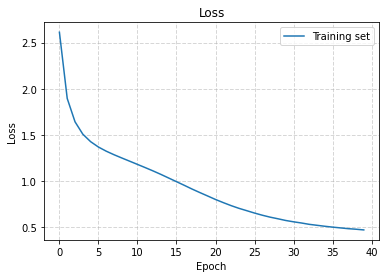

In [ ]:
render_training_history(history)

## Generate text

### Restore the latest checkpoint



In [ ]:
tf.train.latest_checkpoint(checkpoint_dir)

'tmp/checkpoints/ckpt_40'

In [ ]:
simplified_batch_size = 1

model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)

model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))

model.build(tf.TensorShape([simplified_batch_size, None]))

In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (1, None, 256)            16640     
_________________________________________________________________
lstm_1 (LSTM)                (1, None, 1024)           5246976   
_________________________________________________________________
dense_1 (Dense)              (1, None, 65)             66625     
Total params: 5,330,241
Trainable params: 5,330,241
Non-trainable params: 0
_________________________________________________________________


### The prediction loop


## **Lets generate the text now.**

In [ ]:
def generate_text(model, start_string, num_generate=1000, temperature=1.0):

    input_indices = [char2index[s] for s in start_string]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    model.reset_states()
    for char_index in range(num_generate):
        predictions = model(input_indices)
        predictions = tf.squeeze(predictions, 0)
        # squeeze will remove the batch dimensions

        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        input_indices = tf.expand_dims([predicted_id], 0)

        text_generated.append(index2char[predicted_id])

    return start_string + "".join(text_generated)

In [ ]:
# Generate the text with default temperature (1.0).
print(generate_text(model, start_string="ROMEO: "))

ROMEO: IIIUS:
'Twill give thee, that: but thou didst kill my
frostrrs from the Volsces king indeed,
how it was over for that would
inclus from my lord the temperance of your blood,
Even to the consuls in all places of their
fesiness,
As you tarmy, and live and living faith,
With much be grief: le and ten his man.

PETRUCHIO:
The soul enters?
I grave, waiting,
putting one another, it will make you guilty
one me.
Save but thy name should chose him now,
And yet my wits will not provide for you.

GRUMIO:

JULIET:
Must and will not live;
While she appear in her I could fancy morning;
Nothing but middle and despised guide,
May serve the hungry consumperate wishes' crown,
As if my word be holp, by their castles what you married me;
My friendship in the morning 'mage,
The vein clouds, all her scene strinks you have me daughter.

KATHARINA:
No lord that are they came.

GONZALO:
Thou let'st thou make the less! Cannot tell her so blood.

Shepherd:
Why, since he is wondrous winters tears?
And when

In [ ]:
# Generate the text with higher temperature to get more unexpected results.
print(generate_text(model, start_string="ROMEO: ", temperature=1.5))

ROMEO: be so
bound? alasp, sweet drink, thou art the ones in num,
Sunshath thou mean not so! have I either
dism: but this should bush her
Upon 't, all should be helamber too,
Unlikes with keeping playfel. Fare you well.
Thou art schoolmowey 'On hath nurse to death;
Why shakes of catter, tell them well.

KING RICHARD II:
We will go.
I will, as I told you news, so lords.

YORK:
Is it true too, as you shr'w my latther do nt do,
I'ld give't; for I have ins, because my noble lords;
Do kith the prettiest zere reason-bullscent is coming; if you'll swear from
thee!'s a dead man icquiet the haught cursage.

ESCALUS:
Where doth she hast.

BRUTUS:
We know your words.

Firs murder in voice and despair at
Claudioward fort:
But yet, is TERCENTER:
There was KINGHAMped a pitched blows to
she another: take it ave
Of love with custome, as young Master
Your labour sit
That's skilen with insh I violento but a fly say you; if I may,
portain
To a gentleman of finerce,
Bid wour, let us arguing faith with mor

## Save the model

In [ ]:
model_name = "text_generation_shakespeare_rnn.h5"
model.save(model_name, save_format="h5")